<a href="https://colab.research.google.com/github/emgrimm42/NLP-Hausarbeit/blob/main/ha_analyse_and_visualize_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HA Analyse and Visualize a Dataset

In [ ]:
import pandas as pd
import string
import nltk
from nltk.corpus import stopwords
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import numpy as np
from wordcloud import WordCloud
import plotly.graph_objects as go

## Importing Data to the Notebook

In order to access our course data, we clone the course GitHub repository to this notebook. Do do so, run the *git clone* cell below:

In [ ]:
!git clone https://github.com/soberbichler/NLP-Course4Humanities_2025.github.io.git

fatal: destination path 'NLP-Course4Humanities_2025.github.io' already exists and is not an empty directory.


In [ ]:
import pandas as pd

# Replace 'your_file.xlsx' with the actual path to your Excel file.
df = pd.read_excel('/content/Volltext_2751569-2.xlsx')

# Display the first few rows of the DataFrame to verify it's loaded correctly.
df.head(5)

,Unnamed: 0,id,pagenumber,paper_title,provider_ddb_id,provider,zdb_id,publication_date,place_of_distribution,language,thumbnail,pagefulltext,pagename,preview_reference,plainpagefulltext
0,0,IKB4OLLQYFCWSKJE6UJM2QLQ5CAO2RXB-FILE_0001_DDB...,1,Deutsche Zeitung,PE423JPDSCU6C72BAC2PUBOHAINDRGFO,Bayerische Staatsbibliothek,2751569-2,1848-03-08T12:00:00Z,"['Heidelberg', 'Leipzig', 'Frankfurt am Main',...",['ger'],34a5b6cf-d665-4a3f-bb70-2322c7fca675,/data/altos/IK/B4/IKB4OLLQYFCWSKJE6UJM2QLQ5CAO...,FILE_0001_DDB_FULLTEXT,https://api.deutsche-digitale-bibliothek.de/bi...,Alle Poſtämternehmen Be ellnn Die Haupterpedit...
1,1,IKB4OLLQYFCWSKJE6UJM2QLQ5CAO2RXB-FILE_0002_DDB...,2,Deutsche Zeitung,PE423JPDSCU6C72BAC2PUBOHAINDRGFO,Bayerische Staatsbibliothek,2751569-2,1848-03-08T12:00:00Z,"['Heidelberg', 'Leipzig', 'Frankfurt am Main',...",['ger'],34a5b6cf-d665-4a3f-bb70-2322c7fca675,/data/altos/IK/B4/IKB4OLLQYFCWSKJE6UJM2QLQ5CAO...,FILE_0002_DDB_FULLTEXT,https://api.deutsche-digitale-bibliothek.de/bi...,"5Z8 Mittelpunkt, den es nur zu ſtärken, aber n..."
2,2,IKB4OLLQYFCWSKJE6UJM2QLQ5CAO2RXB-FILE_0003_DDB...,3,Deutsche Zeitung,PE423JPDSCU6C72BAC2PUBOHAINDRGFO,Bayerische Staatsbibliothek,2751569-2,1848-03-08T12:00:00Z,"['Heidelberg', 'Leipzig', 'Frankfurt am Main',...",['ger'],34a5b6cf-d665-4a3f-bb70-2322c7fca675,/data/altos/IK/B4/IKB4OLLQYFCWSKJE6UJM2QLQ5CAO...,FILE_0003_DDB_FULLTEXT,https://api.deutsche-digitale-bibliothek.de/bi...,539 beſtimmter Sprache um: die Verleihung eine...
3,3,IKB4OLLQYFCWSKJE6UJM2QLQ5CAO2RXB-FILE_0004_DDB...,4,Deutsche Zeitung,PE423JPDSCU6C72BAC2PUBOHAINDRGFO,Bayerische Staatsbibliothek,2751569-2,1848-03-08T12:00:00Z,"['Heidelberg', 'Leipzig', 'Frankfurt am Main',...",['ger'],34a5b6cf-d665-4a3f-bb70-2322c7fca675,/data/altos/IK/B4/IKB4OLLQYFCWSKJE6UJM2QLQ5CAO...,FILE_0004_DDB_FULLTEXT,https://api.deutsche-digitale-bibliothek.de/bi...,540 Sp. Z.; 1) Unverzügliche Berufung der Stän...
4,4,IKB4OLLQYFCWSKJE6UJM2QLQ5CAO2RXB-FILE_0005_DDB...,5,Deutsche Zeitung,PE423JPDSCU6C72BAC2PUBOHAINDRGFO,Bayerische Staatsbibliothek,2751569-2,1848-03-08T12:00:00Z,"['Heidelberg', 'Leipzig', 'Frankfurt am Main',...",['ger'],34a5b6cf-d665-4a3f-bb70-2322c7fca675,/data/altos/IK/B4/IKB4OLLQYFCWSKJE6UJM2QLQ5CAO...,FILE_0005_DDB_FULLTEXT,https://api.deutsche-digitale-bibliothek.de/bi...,"541 in Bruchſal, in Neckarbiſchofsheim, auch i..."


## Frequency Analysis

In [ ]:
# wandelt die Spalten plainpagefulltext in eine Liste um
content = df['plainpagefulltext'].tolist()
content = [str(text).lower() for text in content if pd.notna(text)]
print(content)

Buffered data was truncated after reaching the output size limit.

In [ ]:
# Removing punctuations and tokenization
listofthings = []
for entry in content:
    for c in string.punctuation:
        entry = entry.replace(c, " ")
    words = entry.split()
    listofthings.extend(words)

In [ ]:
print(listofthings)

Buffered data was truncated after reaching the output size limit.

In [ ]:
# Removing enumerations
words = [word for word in listofthings if not word.isdecimal()]
print(words)

Buffered data was truncated after reaching the output size limit.

In [ ]:
words = [word for word in listofthings if len(word) >= 4]
print(words)

Buffered data was truncated after reaching the output size limit.

#### Removal of stopwords

In [ ]:
nltk.download('stopwords')
stopger = stopwords.words('german')


newStopwords = ["wurde", "wurden", "worden", "heute", "schon", "teil", "zwei", "mehr", "viele", "gestern", "Der", "Die", "das"]


stopger.extend(newStopwords)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:

tokens_without_sw = [word for word in words if word not in stopger]
print(tokens_without_sw)

Buffered data was truncated after reaching the output size limit.

In [ ]:
from nltk import bigrams

# Create bigrams
bigrams_list = list(bigrams(tokens_without_sw))
print(bigrams_list)

# Or as strings
bigrams_strings = [' '.join(bg) for bg in bigrams(tokens_without_sw)]
print(bigrams_strings)

Buffered data was truncated after reaching the output size limit.

In [ ]:
# Counting frequencies
counts = Counter(bigrams_strings)

# Top 20 words
top_20_words = counts.most_common(20)
top_150_words = counts.most_common(150)
print(top_20_words)

[('ſich ſelbſt', 1616), ('frankreich paris', 1206), ('läßt ſich', 1154), ('geſtern abend', 1017), ('deut ſchen', 1008), ('schleswig holſtein', 992), ('national verſammlung', 877), ('großbritannien london', 876), ('deutſchland frankfurt', 843), ('deutſch land', 793), ('zweiten kammer', 788), ('deutſchen zeitung', 700), ('ſchen buchhandlung', 676), ('deutſche zeitung', 665), ('ganz deutſchland', 662), ('regie rung', 646), ('deutſchen staaten', 645), ('buchhandlung leipzig', 640), ('preis beträgt', 633), ('weidmann ſchen', 612)]


## Visualizations

#### 1. Pie chart:

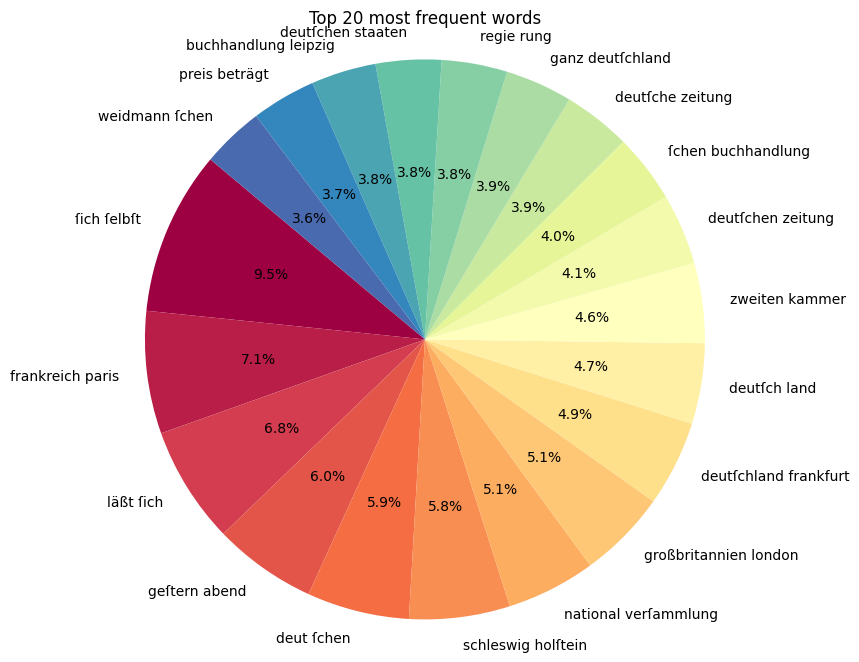

In [ ]:

def create_circle(word_count):
    labels = [word[0] for word in word_count]
    sizes = [word[1] for word in word_count]
    colors = [plt.cm.Spectral(i/float(len(labels))) for i in range(len(labels))]

    plt.figure(figsize=(10, 8))
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
    plt.axis('equal')
    plt.title('Top 20 most frequent words')
    plt.show()


create_circle(top_20_words)

In [ ]:
def tokenize(content):

    wordlist = []
    for word in content.split():
        for char in string.punctuation:
            word = word.strip(char)
        wordlist.append(word)

    words = [word for word in wordlist if not word.isdecimal()]
    tokens_without_sw = [word for word in words if word not in stopger]

    return tokens_without_sw

In [ ]:
# Extract year and month from publication_date
df['year'] = pd.to_datetime(df['publication_date']).dt.year
df['month'] = pd.to_datetime(df['publication_date']).dt.month


# Tokenize - handle NaN values
df['token'] = df['articles'].fillna('').apply(tokenize)


KeyError: 'articles'

In [ ]:
def counting(tokens):
    counts = Counter(tokens)
    return counts

In [ ]:
df['counts'] = df['token'].apply(counting)
df

In [ ]:
import plotly.express as px

word_to_analyze = 'Opfer'
df['year'] = df['year'].astype(int)
df['month'] = df['month'].astype(int)

# Create year-month column for better plotting
df['year_month'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str) + '-01')

word_counts = df[['year_month', 'counts']].copy()
word_counts['count'] = word_counts['counts'].apply(lambda x: x.get(word_to_analyze, 0))
word_counts = word_counts.groupby('year_month')['count'].sum().reset_index()

fig = px.line(word_counts, x='year_month', y='count',
              title=f'Häufigkeit des Wortes "{word_to_analyze}" pro Monat',
              height=550,
              markers=True)

fig.update_layout(
    xaxis_title='Jahr-Monat',
    yaxis_title='Häufigkeit',
    hovermode='x unified'
)

fig.show()

In [ ]:
entry_counts = df.groupby('year_month').size().reset_index(name='entry_count')

fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=word_counts['year_month'], y=word_counts['count'],
                          mode='lines', name=f'Häufigkeit des Wortes "{word_to_analyze}"'))
fig2.add_trace(go.Scatter(x=entry_counts['year_month'], y=entry_counts['entry_count'],
                          mode='lines', name='Anzahl der Einträge'))

fig2.update_layout(
    title=f'Häufigkeit des Wortes "{word_to_analyze}" und Anzahl der Einträge pro Monat',
    xaxis_title='Jahr-Monat',
    yaxis_title='Werte',
    height=550
)

fig2.show()

In [ ]:
words_to_compare = ['Opfer', 'Deutschland', 'Hilfe', 'Krieg']

fig = go.Figure()

# Calculate total words per month
df['total_words'] = df['counts'].apply(lambda x: sum(x.values()))
total_per_month = df.groupby('year_month')['total_words'].sum()

for word in words_to_compare:
    word_counts_temp = df[['year_month', 'counts']].copy()
    word_counts_temp['count'] = word_counts_temp['counts'].apply(lambda x: x.get(word, 0))
    monthly = word_counts_temp.groupby('year_month')['count'].sum()
    relative_freq = (monthly / total_per_month) * 1000  # per 1000 words
    fig.add_trace(go.Scatter(x=relative_freq.index, y=relative_freq.values, mode='lines', name=word))

fig.update_layout(
    title='Relative Worthäufigkeiten (pro 1000 Wörter)',
    xaxis_title='Jahr-Monat',
    yaxis_title='Häufigkeit pro 1000 Wörter',
    height=550
)

fig.show()

In [ ]:
# Co-occurrence within a window (e.g., 5 words before/after)
word_to_analyze = 'Opfer'
window_size = 10

cooccurring_words = {}

for tokens in df['token']:
    if isinstance(tokens, list):  # Make sure it's a list
        for i, word in enumerate(tokens):
            if word == word_to_analyze:
                # Get words within window
                start = max(0, i - window_size)
                end = min(len(tokens), i + window_size + 1)

                for j in range(start, end):
                    if j != i and tokens[j] not in stopger:
                        cooccurring_words[tokens[j]] = cooccurring_words.get(tokens[j], 0) + 1

top_cooccurring = sorted(cooccurring_words.items(), key=lambda x: x[1], reverse=True)[:20]
print(f"Top Wörter innerhalb {window_size} Wörter von '{word_to_analyze}':")
for word, count in top_cooccurring:
    print(f"{word}: {count}")